In [130]:
import pandas as pd
import matplotlib.pyplot as plt

In [131]:
fg = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

In [132]:
fg.sample(5)

,timestamp,value,classification,date
569,1566883800,30,Fear,2019-08-27
981,1602480600,52,Neutral,2020-10-12
1968,1687757400,55,Greed,2023-06-26
680,1576474200,24,Extreme Fear,2019-12-16
67,1523251800,21,Extreme Fear,2018-04-09


In [133]:
trades.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
25843,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,96744.00000,0.66413,64250.59,SELL,15-01-2025 05:42,0.664130,Close Long,166.098913,0xb5a1c00dc8085c252b6c041b79ccb001d700f860e6bc...,63071809583,True,19.275177,5.870000e+14,1.740000e+12
24742,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,107110.00000,0.00012,12.85,SELL,17-12-2024 18:32,-11.625870,Open Short,0.000000,0xd0f883e11394e9209c39041974cb1601d400e3e5ba1d...,56006159421,True,0.003855,8.910000e+14,1.730000e+12
57848,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,@107,16.81700,1.02000,17.15,SELL,19-04-2025 02:48,2076.206964,Sell,0.043837,0x17e6c4c78abcd07e7a550421ce2c5401c600077237ca...,87393709143,True,0.006003,6.640000e+14,1.750000e+12
154814,0x2c229d22b100a7beb69122eed721cee9b24011dd,SEI,0.22966,2322.00000,533.27,SELL,20-02-2025 05:04,732736.000000,Close Long,1.532520,0x4936f4d3a865a209a6d0041e168d7b02018700fdf478...,73515153735,False,0.053327,2.350000e+14,1.740000e+12
183744,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,16.62500,6.01000,99.92,SELL,25-03-2025 18:18,2969.370000,Close Long,2.395586,0x27dbf2c2a522da3f845d04203e23600201ae001af0b8...,81716078821,True,0.029974,7.730000e+14,1.740000e+12


In [134]:
fg['date'] = pd.to_datetime(fg['date']).dt.date
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

In [135]:
merged = trades.merge(fg[['date','classification','value']],
                       on='date', how='left')
print(merged.shape)

(211224, 19)


In [136]:
merged.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
129115,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,MNT,0.73588,67.90,49.97,BUY,19-11-2024 19:34,-155.900000,Close Short,0.099813,0xe2ef43ac55819f870f240417310aff0202730039bdbd...,48512786980,True,0.017488,9.810000e+13,1.730000e+12,2024-11-19,Extreme Greed,90.0
158003,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,18.19500,1.50,27.29,SELL,12-12-2024 14:05,8401.950939,Sell,1.944345,0xfb8fb0deb2812e74e4b204190946350181007f4dedce...,54864979125,True,0.006823,1.010000e+15,1.730000e+12,2024-12-12,Extreme Greed,83.0
94600,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,HYPE,25.27800,25.65,648.38,BUY,17-02-2025 21:51,2998.770000,Open Long,0.000000,0xd563bf01bbf69793be73041df0f7af02052700e7846d...,72931171843,False,0.032419,3.740000e+14,1.740000e+12,2025-02-17,Neutral,51.0
144254,0x39cef799f8b69da1995852eea189df24eb5cae3c,FARTCOIN,0.51201,2082.00,1066.00,SELL,07-04-2025 20:23,-335077.100000,Open Short,0.000000,0x917f2aa895a4926edcc20421162339020698009ba5f2...,84689288542,False,0.106600,5.300000e+14,1.740000e+12,2025-04-07,Extreme Fear,23.0
52407,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,HYPE,12.29300,81.34,999.91,BUY,13-03-2025 18:23,26912.980000,Open Long,0.000000,0x586b1acc06214fea110b041f78f2fc0206cc00f0add7...,79597836161,True,0.349969,4.300000e+13,1.740000e+12,2025-03-13,Neutral,45.0


In [137]:
numeric_column = merged.select_dtypes(include=['number']).columns
string_column = merged.select_dtypes(include=['object']).columns

In [138]:
print("Numeric columns : ",numeric_column)
print("\nString columns : ",string_column)

Numeric columns :  Index(['Execution Price', 'Size Tokens', 'Size USD', 'Start Position',
       'Closed PnL', 'Order ID', 'Fee', 'Trade ID', 'Timestamp', 'value'],
      dtype='object')

String columns :  Index(['Account', 'Coin', 'Side', 'Timestamp IST', 'Direction',
       'Transaction Hash', 'date', 'classification'],
      dtype='object')


In [139]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [140]:
merged.dropna(inplace=True)

In [141]:
merged["Account"].nunique()

32

In [142]:
trader_treynor = merged.groupby('Account').agg(
    avg_return = ('Closed PnL', 'mean'),
    std_return = ('Closed PnL', 'std')
)

risk_free = 0.5

trader_treynor['sharpe_approx'] = (
    (trader_treynor['avg_return'] - risk_free) /
    trader_treynor['std_return']
).round(4)

print(trader_treynor.sort_values(
    'sharpe_approx', ascending=False
).head(3))

                                            avg_return   std_return  \
Account                                                               
0xae5eacaf9c6b9111fd53034a602c192a04e082ed  120.507317   474.809837   
0x6d6a4b953f202f8df5bed40692e7fd865318264a  111.519197   468.995982   
0x420ab45e0bd8863569a5efbb9c05d91f40624641  520.902331  2228.336140   

                                            sharpe_approx  
Account                                                    
0xae5eacaf9c6b9111fd53034a602c192a04e082ed         0.2527  
0x6d6a4b953f202f8df5bed40692e7fd865318264a         0.2367  
0x420ab45e0bd8863569a5efbb9c05d91f40624641         0.2335  


These three accounts took higher risk to achieve the same level of returns.

In [143]:
merged['outcome'] = merged['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Neutral')
)
result = merged.groupby(['classification', 'outcome']).size().unstack(fill_value=0)
print(result)

outcome         Loss  Neutral  Profit
classification                       
Extreme Fear    2475    10994    7931
Extreme Greed   2259    19139   18594
Fear            3789    32029   26019
Greed           5818    25127   19358
Neutral         3198    19527   14961


In [144]:
result['Total']    = result.sum(axis=1)
result['Win Rate'] = (result['Profit'] / result['Total'] * 100).round(2)
print(result)

outcome         Loss  Neutral  Profit  Total  Win Rate
classification                                        
Extreme Fear    2475    10994    7931  21400     37.06
Extreme Greed   2259    19139   18594  39992     46.49
Fear            3789    32029   26019  61837     42.08
Greed           5818    25127   19358  50303     38.48
Neutral         3198    19527   14961  37686     39.70


Two findings together create an interesting tension —
*   Fear has the MOST trades but a LOWER win rate (42%)
*   Extreme Greed has FEWER trades but the HIGHEST win rate (46%)
This means quality beats quantity. Fewer trades during Extreme Greed are more likely to be profitable than the large volume of trades during Fear.

In [145]:
merged['Net PnL'] = merged['Closed PnL'] - merged['Fee']
pnl_by_sent = merged.groupby('classification')['Net PnL'].sum().round(2).sort_values(ascending=False)
print("Net Profit in each segment:\n", pnl_by_sent)

Net Profit in each segment:
 classification
Fear             3264698.49
Extreme Greed    2688140.65
Greed            2087030.58
Neutral          1253546.41
Extreme Fear      715221.61
Name: Net PnL, dtype: float64


Here, Fear generate more total profit despite lower win rate.

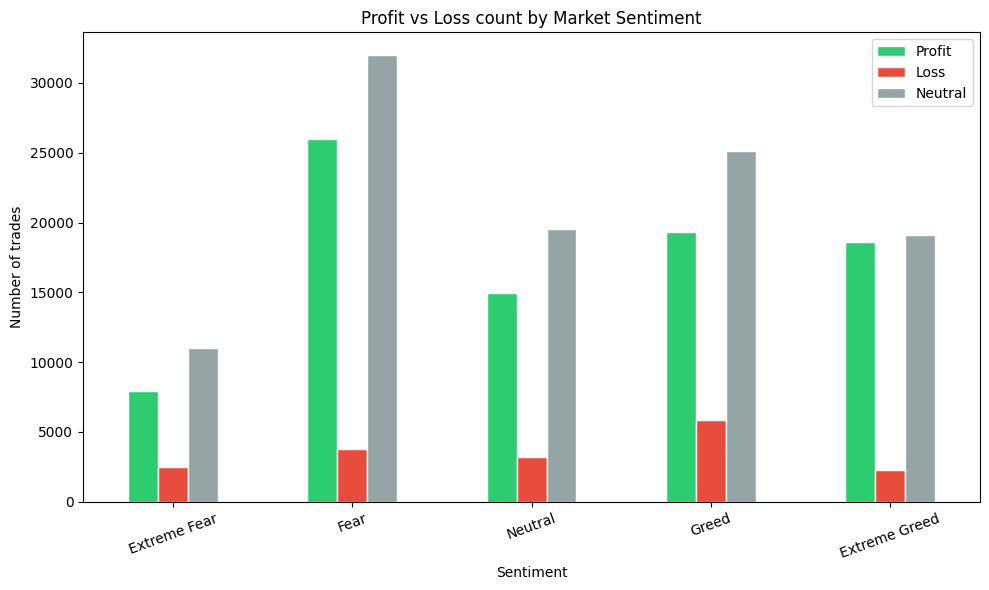

In [146]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

result.loc[order, ['Profit', 'Loss', 'Neutral']].plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c', '#95a5a6'],
    figsize=(10, 6),
    edgecolor='white'
)

plt.title('Profit vs Loss count by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of trades')
plt.xticks(rotation=20)
plt.legend(['Profit', 'Loss', 'Neutral'])
plt.tight_layout()
plt.show()

Conclusion :

*  Fear creates more profit despite having a lower win rate, which clearly demonstrates the contrarian principle.
*  Contrarian principle — skilled traders buy when everyone else is scared and prices are cheap.



In [147]:
merged['PnL %'] = (merged['Net PnL'] / merged['Size USD'] * 100).round(4)
merged['PnL per Token'] = (merged['Net PnL'] / merged['Size Tokens']).round(4)
full_analysis = merged.groupby('classification').agg(
    Avg_PnL_Percent = ('PnL %','mean'),
    Avg_PnL_Per_Token = ('PnL per Token', 'mean')
).round(2)

print(full_analysis.sort_values('Avg_PnL_Per_Token', ascending=False))

                Avg_PnL_Percent  Avg_PnL_Per_Token
classification                                    
Fear                       1.49              30.60
Neutral                    0.95              12.59
Extreme Greed              3.98              11.91
Extreme Fear               0.41              11.35
Greed                      1.94               5.62


Observation :

*   Extreme Greed wins clearly at 3.98%. This means for every dollar 100 put into a trade during Extreme Greed, traders earned dollar 3.98 back on average.
*   Fear dominates massively at dollar 30.60 per token — nearly 3x higher than Extreme Greed (dollar 11.91).

Extreme Greed is better for capital efficiency (PnL %) and Fear is better for per token profit (PnL per Token).


In [148]:
coin_sentiment = merged.groupby(
    ['classification', 'Coin']
).agg(
    Avg_PnL_Pct   = ('PnL %',   'mean'),
    Total_Net_PnL = ('Net PnL', 'sum'),
    Trades        = ('Net PnL', 'count'),
    Win_Rate      = ('Net PnL', lambda x: (x > 0).mean() * 100)
).round(2).reset_index()

coin_sentiment_filtered = coin_sentiment[coin_sentiment['Trades'] >= 50]

sentiment = 'Fear' #@param ['Fear', 'Extreme Fear', 'Extreme Greed', 'Greed', 'Neutral']

result = coin_sentiment_filtered[
    coin_sentiment_filtered['classification'] == sentiment
].sort_values('Avg_PnL_Pct', ascending=False).head(3)

print(f"\nTop coins during {sentiment}:\n")
print(result[['Coin','Avg_PnL_Pct','Total_Net_PnL',
              'Trades','Win_Rate']].to_string(index=False))


Top coins during Fear:

 Coin  Avg_PnL_Pct  Total_Net_PnL  Trades  Win_Rate
   ME        30.31       13849.66     180     71.67
  ENA        26.42      160245.55     193     47.67
USUAL        24.10       45863.43      94     53.19


In Extreme Greed - @85, @107, PURR/USDC and In Fear - ME, ENA, USUAL, top 3 coins give best returns

In [149]:
buy_sell = merged.groupby(
    ['classification', 'Side']
).size().unstack(fill_value=0).reset_index()

buy_sell['Total']      = buy_sell['BUY'] + buy_sell['SELL']
buy_sell['Buy %']      = (buy_sell['BUY']  / buy_sell['Total'] * 100).round(2)
buy_sell['Sell %']     = (buy_sell['SELL'] / buy_sell['Total'] * 100).round(2)

print(buy_sell.to_string(index=False))

classification   BUY  SELL  Total  Buy %  Sell %
  Extreme Fear 10935 10465  21400  51.10   48.90
 Extreme Greed 17940 22052  39992  44.86   55.14
          Fear 30270 31567  61837  48.95   51.05
         Greed 24576 25727  50303  48.86   51.14
       Neutral 18969 18717  37686  50.33   49.67


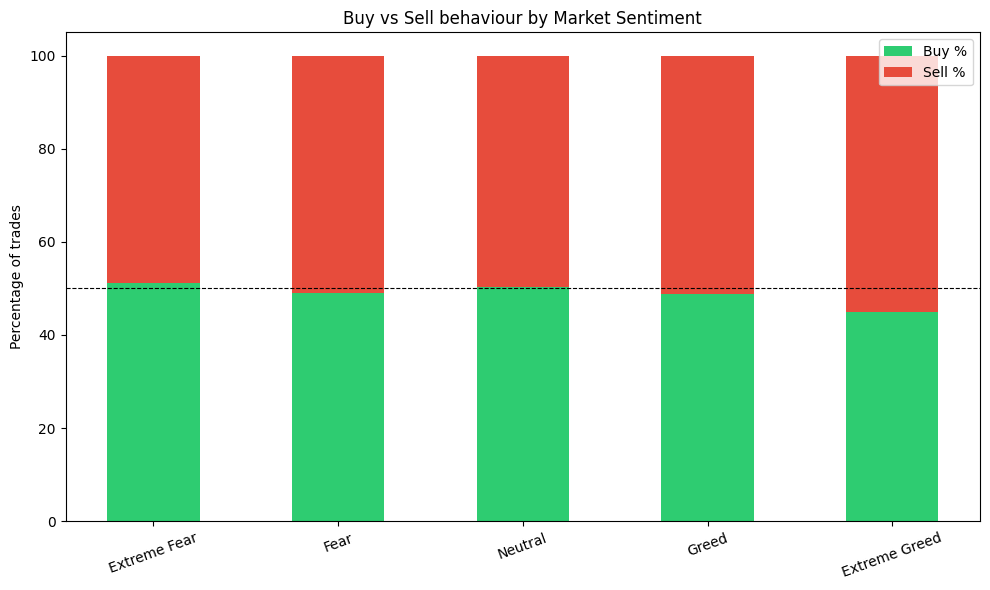

In [150]:
order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

buy_vals  = []
sell_vals = []

for sent in order:
    row = buy_sell[buy_sell['classification'] == sent]
    buy_vals.append(float(row['Buy %'].values[0]))
    sell_vals.append(float(row['Sell %'].values[0]))

x = range(len(order))
width = 0.5

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, buy_vals,  width, label='Buy %',  color='#2ecc71')
ax.bar(x, sell_vals, width, label='Sell %', color='#e74c3c',
       bottom=buy_vals)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20)
ax.set_ylabel('Percentage of trades')
ax.set_title('Buy vs Sell behaviour by Market Sentiment')
ax.legend()
ax.axhline(50, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

This clearly shows that during extreme fear, when people want to sell their trades, traders buy them, and during extreme greed, when people want to buy, traders sell.


Buy/Sell + Crossed pattern during → Fear
Side  Crossed  Trades
 BUY    False   13132
 BUY     True   17138
SELL    False   11548
SELL     True   20019




/tmp/ipykernel_9744/3690144909.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Label'] = result['Side'] + " | Crossed: " + result['Crossed'].astype(str)


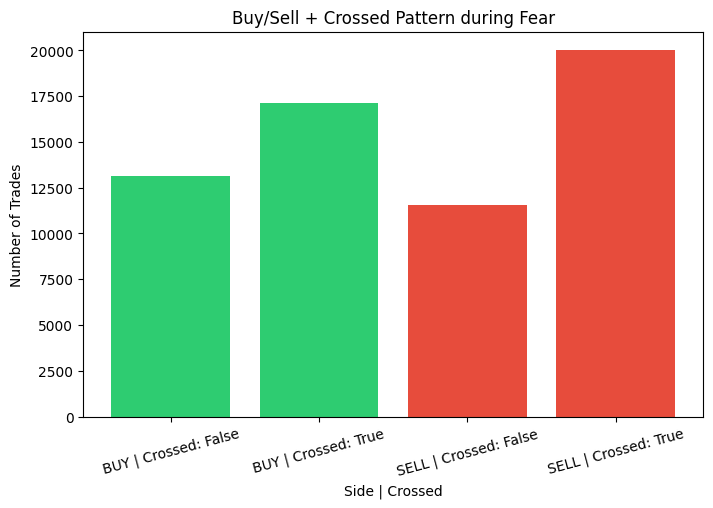

In [151]:
crossed_pattern = merged.groupby(
    ['classification', 'Side', 'Crossed']
).agg(
    Trades = ('Net PnL', 'count'),
).round(2).reset_index()

sentiment = 'Fear' #@param ['Fear', 'Extreme Fear', 'Extreme Greed', 'Greed', 'Neutral']

result = crossed_pattern[crossed_pattern['classification'] == sentiment]
result['Label'] = result['Side'] + " | Crossed: " + result['Crossed'].astype(str)

print(f"\nBuy/Sell + Crossed pattern during → {sentiment}")
print(result[['Side','Crossed','Trades']].to_string(index=False))
print("\n")

colors = result['Side'].map({
    'BUY': '#2ecc71',
    'SELL': '#e74c3c'
})

plt.style.use('default')

plt.figure(figsize=(8,5))

bars = plt.bar(
    result['Label'],
    result['Trades'],
    color=colors
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha='center',
        va='bottom',
        color='white'
    )

plt.xlabel("Side | Crossed")
plt.ylabel("Number of Trades")
plt.title(f"Buy/Sell + Crossed Pattern during {sentiment}")

plt.xticks(rotation=15)

plt.show()

During fear, traders are more impatient to buy and sell trades.

# Final Conclusion :
Here, crowd sentiment affects how much profit traders make. Especially during Fear and Extreme Greed, they earn higher profits.